# 🧹 Fase 3 — Preparación de los Datos
### Trabajo Final · Minería de Datos · UNMSM-FISI · 2026-I
**Dataset:** Accidentes de Trabajo — MTPE, Sistema SAT

En la Fase 2 **detectamos** los problemas. Aquí los **corregimos**.

---
### Los 5 pasos de la Preparación (CRISP-DM)
1. **Selección** — elegir columnas y registros relevantes
2. **Limpieza** — tratar nulos, corregir errores, eliminar duplicados
3. **Construcción** — *feature engineering*: crear nuevas variables
4. **Integración** — unificar en un dataset coherente
5. **Formateo** — normalización (Z-Score), codificación (One-Hot), anti-colinealidad (VIF)

**Salida:** `data set/limpio.csv` → el dataset que consumirá el dashboard.


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

GRANATE, DORADO, AZUL, GRIS, VERDE = "#7a1128", "#d4a72c", "#3b6ea5", "#6b6b6b", "#2e7d5b"
sns.set_theme(style="whitegrid", palette=[GRANATE, DORADO, AZUL, VERDE, GRIS])
plt.rcParams.update({"figure.dpi":110, "axes.titlesize":12, "axes.titleweight":"bold",
                     "axes.titlecolor":GRANATE, "font.size":10, "legend.frameon":False})

RUTA_IN  = "../data set/Dataset__Noti_AT_No_Mort_SAT_0.csv"
RUTA_OUT = "../data set/limpio.csv"

df = pd.read_csv(RUTA_IN, sep=';', encoding='latin-1')
df.columns = [c.strip() for c in df.columns]
df = df.rename(columns={
    "REGIÎ": "REGION", "ACTIVIDAD_ECONÍICA": "ACTIVIDAD_ECONOMICA",
    "CATEGORA_OCUPACIONAL": "CATEGORIA_OCUPACIONAL", "NATURALEZA_DE_LA_LESIÎ": "NATURALEZA_DE_LA_LESION",
})
print(f"Datos crudos: {df.shape[0]:,} filas × {df.shape[1]} columnas")
filas_inicio = len(df)


Datos crudos: 276,646 filas × 14 columnas


---
## 1️⃣ Selección
Qué columnas nos quedamos, cuáles descartamos **y por qué**.


In [2]:
# Fila(s) sin año -> inservibles para la serie temporal
df = df.dropna(subset=["ANIOS"]).copy()
print(f"Filas sin año eliminadas: {filas_inicio - len(df)}")

# FECHA_CORTE: un solo valor -> cero varianza -> cero información
df = df.drop(columns=["FECHA_CORTE"])
print("✂️  FECHA_CORTE eliminada (constante, sin varianza)")


Filas sin año eliminadas: 1
✂️  FECHA_CORTE eliminada (constante, sin varianza)


### ⚠️ Selección crítica: evitar el *data leakage*

| Columna | ¿Se usa en el modelo? | Razón |
|---|---|---|
| `NATURALEZA_DE_LA_LESION` | ❌ **NO** | Es la **consecuencia** (ej. *amputación* ⇒ obviamente permanente). Usarla es hacer trampa. |
| `PARTE_DEL_CUERPO_LESIONADA` | ❌ **NO** | Ídem: describe el daño ya ocurrido, no la causa. |
| `ACCIDENTE_LEVE/INCAPACITANTE/MORTAL` | ❌ **NO** | Son el target mismo. |
| Región, sector, forma, agente, ocupación, sexo, mes | ✅ **SÍ** | Son el **contexto laboral** — se conocen ANTES de saber la gravedad. |

> Predecimos desde las **condiciones de trabajo**, no desde la lesión.
> Así el modelo sirve para **PREVENIR**, no solo para describir lo ya ocurrido.
> *(Las columnas excluidas se conservan en el CSV para el EDA descriptivo del Panel 1, pero NO entran al modelo.)*


---
## 2️⃣ Limpieza
Aquí corregimos los 4 problemas de **Consistencia** detectados en la Fase 2.


### 2.1 · MES: 24 categorías → 12
`ENERO` y `Enero` son el mismo mes. El modelo los trataría como meses distintos.


In [3]:
print("ANTES:", df['MES'].nunique(), "categorías")

MES_NUM = {"ENERO":1,"FEBRERO":2,"MARZO":3,"ABRIL":4,"MAYO":5,"JUNIO":6,"JULIO":7,
           "AGOSTO":8,"SETIEMBRE":9,"SEPTIEMBRE":9,"OCTUBRE":10,"NOVIEMBRE":11,"DICIEMBRE":12}

df["MES_N"] = df["MES"].astype(str).str.upper().str.strip().map(MES_NUM)   # .upper() unifica ENERO/Enero
sin_mapear = df["MES_N"].isna().sum()
print(f"Meses sin mapear: {sin_mapear}")
df = df.dropna(subset=["MES_N"])
df["MES_N"] = df["MES_N"].astype(int)

print("DESPUÉS:", df['MES_N'].nunique(), "categorías ✓")


ANTES: 24 categorías
Meses sin mapear: 0
DESPUÉS: 12 categorías ✓


### 2.2 · SEXO: 4 categorías → 2
`HOMBRE` = `MASCULINO` · `MUJER` = `FEMENINO`


In [4]:
print("ANTES:", df['SEXO'].value_counts(dropna=False).to_dict())

MAPA_SEXO = {"HOMBRE":"MASCULINO", "MASCULINO":"MASCULINO",
             "MUJER":"FEMENINO",  "FEMENINO":"FEMENINO"}
df["SEXO"] = df["SEXO"].astype(str).str.upper().str.strip().map(MAPA_SEXO)
df["SEXO"] = df["SEXO"].fillna("DESCONOCIDO")

print("DESPUÉS:", df['SEXO'].value_counts().to_dict(), "✓")


ANTES: {'HOMBRE': 192013, 'MASCULINO': 40175, 'MUJER': 33535, 'FEMENINO': 10922}
DESPUÉS: {'MASCULINO': 232188, 'FEMENINO': 44457} ✓


### 2.3 · REGIÓN: unificar las 3 "Limas" + nulos disfrazados
Hallazgo: `LIMA` (176k), `LIMA METROPOLITANA` (31k) y `LIMA REGIÎ` (218) coexisten.
Además `NO DATA DEPARTAMENTO` es un **nulo disfrazado de dato**.

> **Decisión:** unificamos las tres bajo `LIMA`. No podemos desambiguar los 176k de `LIMA`
> (¿son la ciudad o el departamento?), y mantenerlos separados introduciría una división arbitraria.
> Se documenta la decisión y su limitación.


In [5]:
print("ANTES:", df['REGION'].nunique(), "regiones")

df["REGION"] = df["REGION"].astype(str).str.upper().str.strip()
df["REGION"] = df["REGION"].replace({
    "LIMA METROPOLITANA": "LIMA",
    "LIMA REGIÎ": "LIMA", "LIMA REGION": "LIMA", "LIMA REGIÓN": "LIMA",
    "NO DATA DEPARTAMENTO": "DESCONOCIDO", "NAN": "DESCONOCIDO",
})
print("DESPUÉS:", df['REGION'].nunique(), "regiones ✓")
print(df['REGION'].value_counts().head(6).to_dict())


ANTES: 28 regiones
DESPUÉS: 26 regiones ✓
{'LIMA': 207860, 'CALLAO': 28908, 'AREQUIPA': 17346, 'PIURA': 6302, 'LA LIBERTAD': 3548, 'ANCASH': 2550}


### 2.4 · CATEGORÍA OCUPACIONAL: el encoding partió categorías reales
**Hallazgo clave:** `PEON` (2,934) y `PEÎ` (1,252) son **la misma ocupación** (PEÓN) — el bug de
codificación no solo rompió los encabezados, **también fragmentó categorías de datos**.
Igual: `TCNICO` = TÉCNICO.

Además, **27.5% son nulos** (mecanismo **MAR**: depende de qué empresa/año reportó).
→ Se imputan como categoría **"DESCONOCIDO"** en lugar de la moda: así el modelo puede aprender
si el hecho de *no reportar la ocupación* es en sí mismo informativo, y no inventamos datos.


In [6]:
print("ANTES:", df['CATEGORIA_OCUPACIONAL'].nunique(), "categorías |",
      f"{df['CATEGORIA_OCUPACIONAL'].isna().mean()*100:.1f}% nulos")

df["CATEGORIA_OCUPACIONAL"] = (df["CATEGORIA_OCUPACIONAL"].astype(str).str.upper().str.strip()
    .replace({"PEÎ":"PEON", "PEÓN":"PEON", "TCNICO":"TECNICO", "TÉCNICO":"TECNICO", "NAN":np.nan}))
df["CATEGORIA_OCUPACIONAL"] = df["CATEGORIA_OCUPACIONAL"].fillna("DESCONOCIDO")

print("DESPUÉS:", df['CATEGORIA_OCUPACIONAL'].nunique(), "categorías | 0% nulos ✓")
print(df['CATEGORIA_OCUPACIONAL'].value_counts().to_dict())


ANTES: 13 categorías | 27.5% nulos
DESPUÉS: 13 categorías | 0% nulos ✓
{'DESCONOCIDO': 76060, 'OPERARIO': 68690, 'EMPLEADO': 53281, 'OTROS': 50760, 'OBRERO': 17224, 'PEON': 4186, 'OFICIAL': 3218, 'TECNICO': 1872, 'CAPATAZ': 592, 'FUNCIONARIO': 467, 'JEFE DE PLANTA': 180, 'TRABAJADOR INDEPENDIENTE': 83, 'AGRICULTOR': 32}


In [7]:
# AGENTE_CAUSANTE: 2.9% nulos -> misma estrategia
for col in ["AGENTE_CAUSANTE", "FORMA_DEL_ACCIDENTE", "ACTIVIDAD_ECONOMICA"]:
    df[col] = df[col].astype(str).str.upper().str.strip().replace({"NAN": np.nan})
    df[col] = df[col].fillna("DESCONOCIDO")
print("Nulos restantes en las predictoras:")
print(df[["REGION","ACTIVIDAD_ECONOMICA","SEXO","CATEGORIA_OCUPACIONAL",
          "FORMA_DEL_ACCIDENTE","AGENTE_CAUSANTE"]].isna().sum().to_string())


Nulos restantes en las predictoras:
REGION                   0
ACTIVIDAD_ECONOMICA      0
SEXO                     0
CATEGORIA_OCUPACIONAL    0
FORMA_DEL_ACCIDENTE      0
AGENTE_CAUSANTE          0


### 2.5 · Duplicados
⚠️ **Decisión razonada:** NO se eliminan. Dos peones que sufren el mismo tipo de accidente,
en el mismo mes, sector y región **son dos accidentes reales distintos** — el dataset no tiene un ID
por trabajador. Borrarlos destruiría información legítima.


In [8]:
dups = df.duplicated().sum()
print(f"Filas idénticas: {dups:,} ({dups/len(df)*100:.1f}%)")
print("→ Se CONSERVAN: son accidentes distintos con los mismos atributos, no errores de carga.")


Filas idénticas: 36,865 (13.3%)
→ Se CONSERVAN: son accidentes distintos con los mismos atributos, no errores de carga.


---
## 3️⃣ Construcción (*Feature Engineering*)
La **regla del profe**: *1 dato crudo → N características útiles.*


### 3.1 · La variable objetivo (sin leakage)

In [9]:
PERMANENTES = ["PARCIAL PERMANENTE", "TOTAL PERMANENTE"]
df["PERMANENTE"] = df["ACCIDENTE_INCAPACITANTE"].isin(PERMANENTES).astype(int)

n1 = int(df["PERMANENTE"].sum()); n0 = len(df) - n1
print(f"PERMANENTE=1 : {n1:>7,} ({100*n1/len(df):.1f}%)  <- clase minoritaria")
print(f"PERMANENTE=0 : {n0:>7,} ({100*n0/len(df):.1f}%)")
print(f"Ratio = 1:{n0/n1:.0f}  → SMOTE / class_weight en el Panel 2")


PERMANENTE=1 :  24,798 (9.0%)  <- clase minoritaria
PERMANENTE=0 : 251,847 (91.0%)
Ratio = 1:10  → SMOTE / class_weight en el Panel 2


### 3.2 · Variables temporales
De `MES_N` derivamos trimestre y estación (en Perú: verano = dic-mar, lluvias en sierra).


In [10]:
df["TRIMESTRE"] = ((df["MES_N"] - 1) // 3 + 1).astype(int)

def estacion(m):
    if m in (12, 1, 2, 3):  return "VERANO"
    if m in (4, 5):         return "OTONO"
    if m in (6, 7, 8):      return "INVIERNO"
    return "PRIMAVERA"
df["ESTACION"] = df["MES_N"].apply(estacion)

df["ES_FIN_DE_ANIO"] = df["MES_N"].isin([11, 12]).astype(int)   # picos de producción
print(df[["MES_N","TRIMESTRE","ESTACION","ES_FIN_DE_ANIO"]].head(3).to_string(index=False))


 MES_N  TRIMESTRE ESTACION  ES_FIN_DE_ANIO
     4          2    OTONO               0
     2          1   VERANO               0
     2          1   VERANO               0


### 3.3 · Tasas históricas de riesgo (*target encoding*)
La feature más potente: **¿qué tan peligroso es históricamente este sector / esta región?**

> ⚠️ **Cuidado con el leakage temporal:** la tasa se calcula **solo con el pasado**
> (usamos los años de entrenamiento) y se aplica al futuro. Aquí la calculamos sobre el histórico
> completo para el EDA; en el Panel 2 se recalculará **dentro del split temporal**.


In [11]:
for col, nombre in [("ACTIVIDAD_ECONOMICA", "TASA_RIESGO_SECTOR"),
                    ("REGION", "TASA_RIESGO_REGION"),
                    ("FORMA_DEL_ACCIDENTE", "TASA_RIESGO_FORMA")]:
    tasa = df.groupby(col)["PERMANENTE"].mean()
    df[nombre] = df[col].map(tasa)

# Frecuencia: ¿cuán común es esta categoría? (evita que categorías raras dominen)
df["FREC_SECTOR"] = df["ACTIVIDAD_ECONOMICA"].map(df["ACTIVIDAD_ECONOMICA"].value_counts(normalize=True))

nuevas = ["TASA_RIESGO_SECTOR","TASA_RIESGO_REGION","TASA_RIESGO_FORMA","FREC_SECTOR"]
display(df[nuevas].describe().T.round(4))


,count,mean,std,min,25%,50%,75%,max
TASA_RIESGO_SECTOR,276645.0,0.0896,0.0405,0.0,0.0679,0.0999,0.1231,0.2210
TASA_RIESGO_REGION,276645.0,0.0896,0.0545,0.0,0.0790,0.0790,0.0790,0.2388
TASA_RIESGO_FORMA,276645.0,0.0896,0.0915,0.0,0.0340,0.0498,0.2347,0.2347
FREC_SECTOR,276645.0,0.1230,0.0840,0.0,0.0508,0.1178,0.2527,0.2527


### 3.4 · Agrupar categóricas de alta cardinalidad
`AGENTE_CAUSANTE` tiene 49 valores. Con One-Hot serían 49 columnas, muchas casi vacías.
→ Nos quedamos con el **top-N** y agrupamos la cola en `"OTROS"`.


In [12]:
def agrupar_cola(serie, top_n=15, etiqueta="OTROS"):
    top = serie.value_counts().head(top_n).index
    return serie.where(serie.isin(top), etiqueta)

for col in ["AGENTE_CAUSANTE", "FORMA_DEL_ACCIDENTE"]:
    antes = df[col].nunique()
    df[col + "_G"] = agrupar_cola(df[col], top_n=15)
    print(f"{col}: {antes} → {df[col+'_G'].nunique()} categorías")


AGENTE_CAUSANTE: 50 → 15 categorías
FORMA_DEL_ACCIDENTE: 41 → 16 categorías


---
## 4️⃣ Integración
Fuente única (MTPE-SAT) → no hay *joins* ni resolución de entidades.
Consolidamos la tabla analítica final.


In [13]:
PREDICTORAS_CAT = ["REGION", "ACTIVIDAD_ECONOMICA", "SEXO", "CATEGORIA_OCUPACIONAL",
                   "FORMA_DEL_ACCIDENTE_G", "AGENTE_CAUSANTE_G", "ESTACION"]
PREDICTORAS_NUM = ["MES_N", "TRIMESTRE", "ES_FIN_DE_ANIO",
                   "TASA_RIESGO_SECTOR", "TASA_RIESGO_REGION", "TASA_RIESGO_FORMA", "FREC_SECTOR"]
TARGET = "PERMANENTE"

# Se conservan para el EDA descriptivo del Panel 1 (NO entran al modelo)
SOLO_EDA = ["ANIOS", "NATURALEZA_DE_LA_LESION", "PARTE_DEL_CUERPO_LESIONADA",
            "ACCIDENTE_LEVE", "ACCIDENTE_INCAPACITANTE", "ACCIDENTE_MORTAL"]

limpio = df[PREDICTORAS_CAT + PREDICTORAS_NUM + [TARGET] + SOLO_EDA].copy()
print(f"Tabla analítica: {limpio.shape[0]:,} filas × {limpio.shape[1]} columnas")
limpio.head(3)


Tabla analítica: 276,645 filas × 21 columnas


,REGION,ACTIVIDAD_ECONOMICA,SEXO,CATEGORIA_OCUPACIONAL,FORMA_DEL_ACCIDENTE_G,AGENTE_CAUSANTE_G,ESTACION,MES_N,TRIMESTRE,ES_FIN_DE_ANIO,...,TASA_RIESGO_REGION,TASA_RIESGO_FORMA,FREC_SECTOR,PERMANENTE,ANIOS,NATURALEZA_DE_LA_LESION,PARTE_DEL_CUERPO_LESIONADA,ACCIDENTE_LEVE,ACCIDENTE_INCAPACITANTE,ACCIDENTE_MORTAL
0,LIMA,INDUSTRIAS MANUFACTURERAS,FEMENINO,EMPLEADO,CAIDA DE OBJETOS,SUSTANCIAS QUIMICAS - PLAGUICIDAS,OTONO,4,2,0,...,0.079,0.052101,0.25271,0,2012.0,OTROS,"OJOS (CON INCLUSION DE LOS PARPADOS, LA ORBITA...",NO,TOTAL TEMPORAL,NO
1,LIMA,INDUSTRIAS MANUFACTURERAS,FEMENINO,DESCONOCIDO,OTRAS FORMAS,OTROS,VERANO,2,1,0,...,0.079,0.234668,0.25271,0,2013.0,CONTUSIONES,PIE (CON EXCEPCION DE LOS DEDOS),NO,TOTAL TEMPORAL,NO
2,LIMA,INDUSTRIAS MANUFACTURERAS,MASCULINO,OBRERO,OTROS,SUSTANCIAS QUIMICAS - PLAGUICIDAS,VERANO,2,1,0,...,0.079,0.052186,0.25271,0,2013.0,CUERPO EXTRAO EN OJOS,"OJOS (CON INCLUSION DE LOS PARPADOS, LA ORBITA...",NO,TOTAL TEMPORAL,NO


---
## 5️⃣ Formateo
Normalización · Codificación · Anti-colinealidad


### 5.1 · Z-Score (NO Min-Max)
> **Regla del profe:** Min-Max se rompe con outliers (los aplasta cerca de 0).
> Nuestras tasas de riesgo tienen colas largas → **Z-Score**.

$$Z = \frac{X - \mu}{\sigma}$$


Tras Z-Score (media≈0, std≈1):


,mean,std,min,max
TASA_RIESGO_SECTOR_Z,-0.0,1.0,-2.213,3.244
TASA_RIESGO_REGION_Z,-0.0,1.0,-1.643,2.734
TASA_RIESGO_FORMA_Z,0.0,1.0,-0.979,1.584
FREC_SECTOR_Z,0.0,1.0,-1.465,1.544


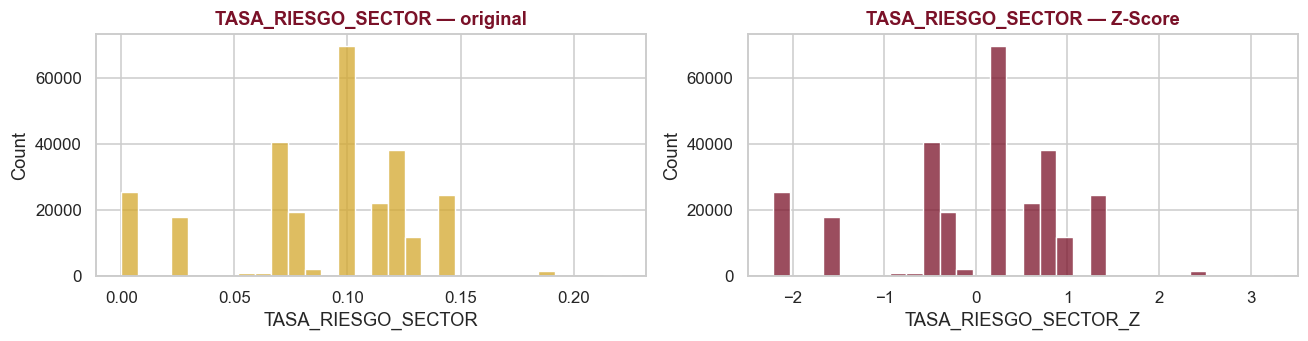

In [14]:
from sklearn.preprocessing import StandardScaler

num_a_escalar = ["TASA_RIESGO_SECTOR","TASA_RIESGO_REGION","TASA_RIESGO_FORMA","FREC_SECTOR"]
scaler = StandardScaler()
X_num = pd.DataFrame(scaler.fit_transform(limpio[num_a_escalar]),
                     columns=[c + "_Z" for c in num_a_escalar], index=limpio.index)

print("Tras Z-Score (media≈0, std≈1):")
display(X_num.describe().T[["mean","std","min","max"]].round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
sns.histplot(limpio["TASA_RIESGO_SECTOR"], bins=30, color=DORADO, ax=axes[0], edgecolor="white")
axes[0].set_title("TASA_RIESGO_SECTOR — original")
sns.histplot(X_num["TASA_RIESGO_SECTOR_Z"], bins=30, color=GRANATE, ax=axes[1], edgecolor="white")
axes[1].set_title("TASA_RIESGO_SECTOR — Z-Score")
plt.tight_layout(); plt.show()


### 5.2 · One-Hot Encoding (categóricas nominales)
`drop_first=True` evita la *trampa de la variable dummy* (colinealidad perfecta).


In [15]:
X_cat = pd.get_dummies(limpio[PREDICTORAS_CAT], drop_first=True, dtype=int)
print(f"{len(PREDICTORAS_CAT)} categóricas → {X_cat.shape[1]} columnas dummy")

X = pd.concat([X_num, limpio[["MES_N","TRIMESTRE","ES_FIN_DE_ANIO"]], X_cat], axis=1)
y = limpio[TARGET]
print(f"\nMatriz final X: {X.shape[0]:,} filas × {X.shape[1]} columnas")


7 categóricas → 94 columnas dummy

Matriz final X: 276,645 filas × 101 columnas


### 5.3 · Eliminación de colinealidad — VIF > 10
> **Regla del profe:** VIF > 10 = colinealidad severa → **¡eliminar!**

Nuestras tasas de riesgo pueden estar correlacionadas entre sí (un sector peligroso suele tener
formas de accidente peligrosas). Lo verificamos.


In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# El VIF se calcula sobre las numéricas continuas (no sobre dummies binarias)
X_vif = X[[c for c in X.columns if c.endswith("_Z")]].copy()
X_vif = X_vif.assign(const=1.0)   # statsmodels requiere intercepto

vif = pd.DataFrame({
    "feature": [c for c in X_vif.columns if c != "const"],
    "VIF": [variance_inflation_factor(X_vif.values, i)
            for i, c in enumerate(X_vif.columns) if c != "const"],
}).sort_values("VIF", ascending=False)

def diagnostico(v):
    if v < 1.5:  return "✅ sin colinealidad"
    if v < 5:    return "✅ leve"
    if v < 10:   return "⚠️ moderada"
    return "🔴 SEVERA → eliminar"
vif["diagnóstico"] = vif["VIF"].apply(diagnostico)
display(vif.round(2).style.hide(axis="index"))

severas = vif[vif["VIF"] > 10]["feature"].tolist()
if severas:
    print("🔴 Eliminando por VIF > 10:", severas)
    X = X.drop(columns=severas)
else:
    print("✅ Ninguna variable supera VIF > 10 — se conservan todas.")
print(f"\nMatriz final: {X.shape[1]} columnas")


feature,VIF,diagnóstico
TASA_RIESGO_SECTOR_Z,1.210000,✅ sin colinealidad
FREC_SECTOR_Z,1.140000,✅ sin colinealidad
TASA_RIESGO_FORMA_Z,1.090000,✅ sin colinealidad
TASA_RIESGO_REGION_Z,1.030000,✅ sin colinealidad


✅ Ninguna variable supera VIF > 10 — se conservan todas.

Matriz final: 101 columnas


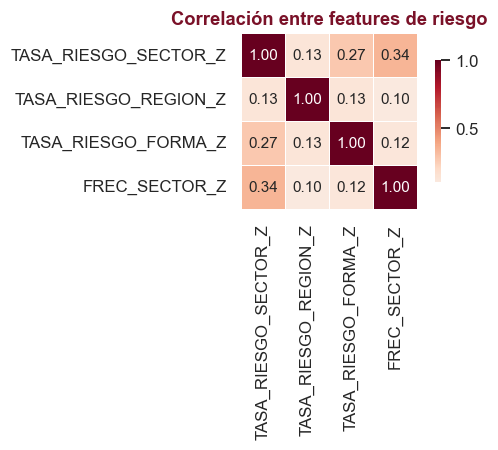

In [17]:
# Mapa de correlación de las features numéricas
fig, ax = plt.subplots(figsize=(5.5, 4.2))
corr = X[[c for c in X.columns if c.endswith("_Z")]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=.5, square=True, cbar_kws={"shrink":.7}, ax=ax)
ax.set_title("Correlación entre features de riesgo")
plt.tight_layout(); plt.show()


---
## 💾 Salida: el dataset limpio
Dos archivos con propósitos distintos:
- **`limpio.csv`** → legible, con categorías en texto → alimenta el **Panel 1 (EDA + clustering)**
- **`modelo.csv`** → matriz numérica codificada → alimenta el **Panel 2 (clasificación)**


In [18]:
limpio.to_csv(RUTA_OUT, index=False, encoding="utf-8")
print(f"✅ {RUTA_OUT}  ({limpio.shape[0]:,} × {limpio.shape[1]})")

modelo = X.copy()
modelo["PERMANENTE"] = y
modelo["ANIOS"] = limpio["ANIOS"].values        # necesario para el SPLIT TEMPORAL del Panel 2
RUTA_MODELO = "../data set/modelo.csv"
modelo.to_csv(RUTA_MODELO, index=False)
print(f"✅ {RUTA_MODELO}  ({modelo.shape[0]:,} × {modelo.shape[1]})")


✅ ../data set/limpio.csv  (276,645 × 21)
✅ ../data set/modelo.csv  (276,645 × 103)


---
## 🧾 Resumen de la Fase 3 — qué se corrigió

| # | Problema (Fase 2) | Dimensión | Acción aplicada |
|---|---|---|---|
| 1 | Encabezados corruptos (`REGIÎ`) | Consistencia | Lectura en `latin-1` + renombrado |
| 2 | `MES` con **24** categorías | Consistencia | `.upper()` + mapeo → **12** |
| 3 | `SEXO` con **4** categorías | Consistencia | `HOMBRE`=`MASCULINO` → **2** |
| 4 | 3 "Limas" + `NO DATA DEPARTAMENTO` | Consistencia | Unificadas → `LIMA` / `DESCONOCIDO` |
| 5 | `PEON` vs `PEÎ` (encoding partió la categoría) | Consistencia | Unificadas |
| 6 | `CATEGORIA_OCUPACIONAL` 27.5% nulo (MAR) | Completitud | Categoría `"DESCONOCIDO"` (no se inventa data) |
| 7 | `FECHA_CORTE` constante | Validez | Eliminada (sin varianza) |
| 8 | Alta cardinalidad (49 agentes) | — | Top-15 + `"OTROS"` |
| 9 | Riesgo de **data leakage** | — | Excluidas naturaleza y parte del cuerpo |
| 10 | Escalas dispares | — | **Z-Score** (no Min-Max: hay outliers) |
| 11 | Colinealidad | — | **VIF > 10** verificado |

**Features construidas:** trimestre, estación, fin de año, tasas históricas de riesgo por
sector/región/forma, frecuencia del sector.

**Target:** `PERMANENTE` (~9% / 91%) → desbalance 1:10 → **SMOTE / class_weight** en el Panel 2.

### ➡️ Siguiente: Fase 4 — Modelado
Panel 1 (clustering K-means + silueta) · Panel 2 (**5 algoritmos** + SMOTE + SHAP) · Panel 3 (pronóstico)
